# Neural control of a Sano ribbon from a single observed coordinate

This notebook is a variant of `neural_control_sano.ipynb` with the same ribbon, clamps, teacher target, naive ramp, network and optimizer. **The only change is the supervision.** There the loss compared the *full* configuration (every node position and twist angle) with the target at every continuation step. Here the loss sees **one scalar per step: the height $z_\text{mid}$ of the middle node.**

**Sparse supervision, dense gradient.** The loss reads one coordinate of $q_k$, but $q_k$ is an equilibrium $\nabla_x E(x_k, z_k)=0$ that depends on every free DOF. The equilibrium adjoint
$$\frac{d\mathcal L}{dz_k} = -\Big(\frac{\partial^2E}{\partial x\,\partial z}\Big)^{\!\top}\!\Big(\frac{\partial^2E}{\partial x^2}\Big)^{-1}\frac{\partial\mathcal L}{\partial x_k}$$
solves with the full Hessian. So the one-hot sensitivity $\partial\mathcal L/\partial x_k = e_\text{mid}$ is spread over the whole ribbon: the network is trained through the mechanics of every node and every twist, not only the observed one. Warm starting also makes each step depend on the previous one, so the adjoint carries this information back along the path.

**Sano's model.** A ribbon has a hard axis 1 and an easy axis 2. Sano's energy couples easy-axis bending and twist with a regularization length $\zeta$:

$$e = e_\text{DER} + \tfrac12 EI_2\,\frac{\tau^4}{\zeta^{-2}+\kappa_2^2}.$$

In [1]:
import math, time
import equinox as eqx
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from dismech_jax import Geometry, Material, Sano, make_rod

jax.config.update("jax_enable_x64", True)

## 1. The ribbon and its boundary DOFs

The ribbon lies flat in the $xy$ plane with width along $y$ (`d1`). Bending about the width axis (easy, $EI_2=7.85\times10^{-8}$ N·m², kappa2) is 100x softer than in-plane bending ($EI_1$). No gravity.

We clamp nodes 0, 1 and the last two nodes (including the edge twist DOF). The left clamp is actuated by $(p_x,\beta,\vartheta)$: node 0 moves to $x=p_x$, node 1 sits at $p_x+\Delta\ell\cos\beta$, $z=-\Delta\ell\sin\beta$, and the first edge's twist angle is $\vartheta$. Positive $p_x$ compresses the ribbon.

In [2]:
N, L = 41, 1.0
dl = L / (N - 1)
ZETA = 0.1
geom = Geometry(length=L, r0=1e-3, axs=3.14e-6, ixs1=7.85e-11, ixs2=7.85e-13, jxs=2e-12)  # EA=0.314, EI1=7.85e-6, EI2=7.85e-8
mat = Material(density=1200.0, youngs_rod=1e5, poisson_rod=0.3)
model = Sano.from_legacy(geom, mat, ZETA)

left = np.arange(7)  # node 0 (x,y,z,theta) and node 1 (x,y,z)
right = np.array([4 * (N - 2) + i for i in range(4)] + [4 * (N - 1) + i for i in range(3)])
rod, aux0 = make_rod(geom, mat, N=N, fixed=jnp.asarray(np.concatenate([left, right])),
                     gravity=jnp.zeros(3), model=model)

zpos = {int(d): i for i, d in enumerate(np.asarray(rod.idx_z))}  # position of each DOF in `z`
MID = 4 * (N // 2)  # first DOF of the middle node

def pose_to_zs(pose):
    # pose: (K, 3) = (px, pitch, twist) of the left clamp -> fixed DOFs `zs` (K, n_z)
    px, pitch, tw = pose.T
    zs = jnp.tile(rod.z0, (pose.shape[0], 1))
    zs = zs.at[:, zpos[0]].set(px).at[:, zpos[3]].set(tw)
    return zs.at[:, zpos[4]].set(px + dl * jnp.cos(pitch)).at[:, zpos[6]].set(-dl * jnp.sin(pitch))

def min_eig(xs, zs):
    # smallest eigenvalue of the free-DOF Hessian at every step (>0 <=> stable equilibrium)
    def f(a, xz):
        H, _ = rod.hessian(*xz, a)
        return rod.update(a, *xz), jnp.linalg.eigvalsh(H)[0]
    return jax.lax.scan(f, aux0, (xs, zs))[1]

def diagnose(pose):
    # solve a boundary path and report whether it stays on a stable, converged branch
    zs = pose_to_zs(pose)
    xs, res = rod.solve(zs, aux0, iters=30)
    lam = np.asarray(min_eig(xs, zs))
    bad = (lam < -1e-9) | (np.asarray(res) > 1e-6)
    return dict(xs=xs, zs=zs, q=rod.join(xs, zs), lam=lam, res=np.asarray(res), bad=bad)

def ramp(t, a, b):
    return jnp.clip((t - a) / (b - a), 0.0, 1.0)

## 2. Target shape and the naive path

The target is a **stable, twisted and buckled** equilibrium. We define it with a teacher schedule that first tilts and twists the clamp (which picks the buckling direction) and only then compresses, so every step is a stable equilibrium. The network never sees this schedule, only the target shape.

The naive schedule reaches the **same final clamp pose** but moves all three controls together. It crosses an unstable bifurcation, snaps, and lands on the other buckling branch.

In [3]:
K = 200
tau_t = jnp.linspace(0, 1, K)
FINAL = jnp.array([0.2, 0.3, math.pi])  # final (px, pitch, twist)

teacher = jnp.stack([FINAL[0] * ramp(tau_t, .5, 1), FINAL[1] * ramp(tau_t, 0, .5), FINAL[2] * ramp(tau_t, 0, .5)], 1)
naive = tau_t[:, None] * FINAL

D = {"teacher (target)": diagnose(teacher), "naive linear ramp": diagnose(naive)}
for name, d in D.items():
    print(f"{name:18s} unstable/unconverged steps: {int(d['bad'].sum()):3d}   "
          f"mid-node height z = {float(d['q'][-1, MID + 2]):+.3f}")
q_target = D["teacher (target)"]["q"][-1]

teacher (target)   unstable/unconverged steps:   0   mid-node height z = -0.239
naive linear ramp  unstable/unconverged steps:   8   mid-node height z = +0.201


## 2b. What the loss is allowed to see

Only the mid-node height trajectory $h_k = z_\text{mid}(q_k)$ and its target value at the end. The full shape vector `shape_vec` is kept **only for evaluation** and never enters the loss.

In [4]:
def shape_vec(q):  # evaluation only, never used in the loss
    P = jnp.stack([q[0::4], q[1::4], q[2::4]], 1)
    return jnp.concatenate([P.ravel() / L, 0.1 * q[3::4]])

sv_target = shape_vec(q_target)
scale = jnp.mean((sv_target - shape_vec(rod.q0)) ** 2)

z_target = q_target[MID + 2]  # the only target information the loss gets
print(f"target mid-node height {float(z_target):+.4f}")

target mid-node height -0.2392


## 3. Neural controller, rollout and midpoint-only loss

The controller and rollout are unchanged: an MLP gives the **rates** of $(p_x,\beta,\vartheta)$ over $K=200$ continuation steps, initialized to the naive ramp that snaps.

Both loss terms now use only the mid-node height $h_k$:

$$\mathcal L=\underbrace{\frac{(h_K-h^*)^2}{h^{*2}}}_{\text{reach the target height}}+\lambda\,\underbrace{\frac{K\max_k (h_k-h_{k-1})^2}{h^{*2}}}_{\text{no snap}}$$

A snap between the up and down buckling branches is a jump in $h$, so the midpoint alone can detect it. With this weaker signal the snap term needs a larger weight ($\lambda=3\times10^{-3}$ instead of $3\times10^{-4}$) and Adam a smaller step ($3\times10^{-3}$ instead of $10^{-2}$). With the original settings the height is matched but training keeps jumping between branches and ends with unstable steps.

In [5]:
taus = jnp.linspace(0, 1, K + 1)[1:]
u_max = jnp.array([0.5, 1.0, 2 * math.pi])
LAMBDA, LR = 3e-3, 3e-3

net = eqx.nn.MLP(1, 3, 32, 2, activation=jnp.tanh, key=jax.random.PRNGKey(0))
net = eqx.tree_at(lambda n: n.layers[-1].weight, net, net.layers[-1].weight * 0.1)
net = eqx.tree_at(lambda n: n.layers[-1].bias, net, jnp.arctanh(FINAL / u_max))  # start at the naive ramp

def rollout(net):
    u = jax.vmap(lambda t: u_max * jnp.tanh(net(t[None])))(taus)   # boundary rates
    pose = jnp.cumsum(u / K, axis=0)
    zs = pose_to_zs(pose)
    xs, res = rod.solve(zs, aux0, iters=30)                         # equilibrium at each step
    return pose, xs, zs, res

def loss_fn(net):
    pose, xs, zs, res = rollout(net)
    h = rod.join(xs, zs)[:, MID + 2]                                # observe only the mid-node height
    height = (h[-1] - z_target) ** 2 / z_target ** 2
    snap = K * jnp.max(jnp.diff(h) ** 2) / z_target ** 2
    return height + LAMBDA * snap, (height, snap, pose, xs, zs, res)

loss_and_grad = eqx.filter_jit(eqx.filter_value_and_grad(loss_fn, has_aux=True))

## 4. Training (Adam, exact gradients through the equilibrium solves)

In [6]:
def adam_step(params, grads, state, lr=LR, b1=0.9, b2=0.999):
    m, v, t = state; t += 1
    m = jax.tree.map(lambda a, g: b1 * a + (1 - b1) * g, m, grads)
    v = jax.tree.map(lambda a, g: b2 * a + (1 - b2) * g * g, v, grads)
    step = jax.tree.map(lambda a, b: lr * (a / (1 - b1 ** t)) / (jnp.sqrt(b / (1 - b2 ** t)) + 1e-8), m, v)
    return jax.tree.map(lambda p, s: p - s, params, step), (m, v, t)

params, static = eqx.partition(net, eqx.is_inexact_array)
state = (jax.tree.map(jnp.zeros_like, params), jax.tree.map(jnp.zeros_like, params), 0)
history, t0 = [], time.time()
for it in range(200):
    (loss, (height, snap, pose, xs, zs, res)), grads = loss_and_grad(eqx.combine(params, static))
    params, state = adam_step(params, eqx.filter(grads, eqx.is_inexact_array), state)
    history.append((float(loss), float(height), float(snap)))
    if it % 25 == 0:
        print(f"iter {it:3d}  loss {float(loss):.3e}  height {float(height):.3e}  snap {float(snap):.1e}  "
              f"max Newton residual {float(res.max()):.1e}  ({time.time()-t0:.0f}s)")
net = eqx.combine(params, static)

iter   0  loss 3.576e+00  height 3.522e+00  snap 1.8e+01  max Newton residual 5.6e-04  (6s)


iter  25  loss 1.012e-01  height 3.627e-05  snap 3.4e+01  max Newton residual 2.4e-04  (33s)


iter  50  loss 3.158e-02  height 1.263e-02  snap 6.3e+00  max Newton residual 1.2e-02  (59s)


iter  75  loss 1.422e-02  height 1.121e-02  snap 1.0e+00  max Newton residual 1.3e-06  (89s)


iter 100  loss 2.562e-04  height 1.557e-04  snap 3.3e-02  max Newton residual 9.6e-11  (115s)


iter 125  loss 1.283e-04  height 1.415e-05  snap 3.8e-02  max Newton residual 9.0e-11  (141s)


iter 150  loss 1.161e-04  height 3.958e-07  snap 3.9e-02  max Newton residual 9.9e-11  (167s)


iter 175  loss 1.126e-04  height 1.486e-07  snap 3.7e-02  max Newton residual 9.4e-11  (192s)


## 5. Result: a stable path, judged on the full shape it never saw

In [7]:
pose, *_ = rollout(net)
D["trained controller"] = diagnose(pose)
for name, d in D.items():
    err = float(jnp.mean((shape_vec(d['q'][-1]) - sv_target) ** 2) / scale)
    print(f"{name:20s} unstable/unconverged steps: {int(d['bad'].sum()):3d}   "
          f"mid-node z = {float(d['q'][-1, MID + 2]):+.3f}   full-shape error (unseen) {err:.2e}   "
          f"final min Hessian eig {d['lam'][-1]:.1e}")

teacher (target)     unstable/unconverged steps:   0   mid-node z = -0.239   full-shape error (unseen) 0.00e+00   final min Hessian eig 4.3e-08
naive linear ramp    unstable/unconverged steps:   8   mid-node z = +0.201   full-shape error (unseen) 1.25e+00   final min Hessian eig 3.1e-08
trained controller   unstable/unconverged steps:   0   mid-node z = -0.240   full-shape error (unseen) 1.34e-01   final min Hessian eig 4.5e-08


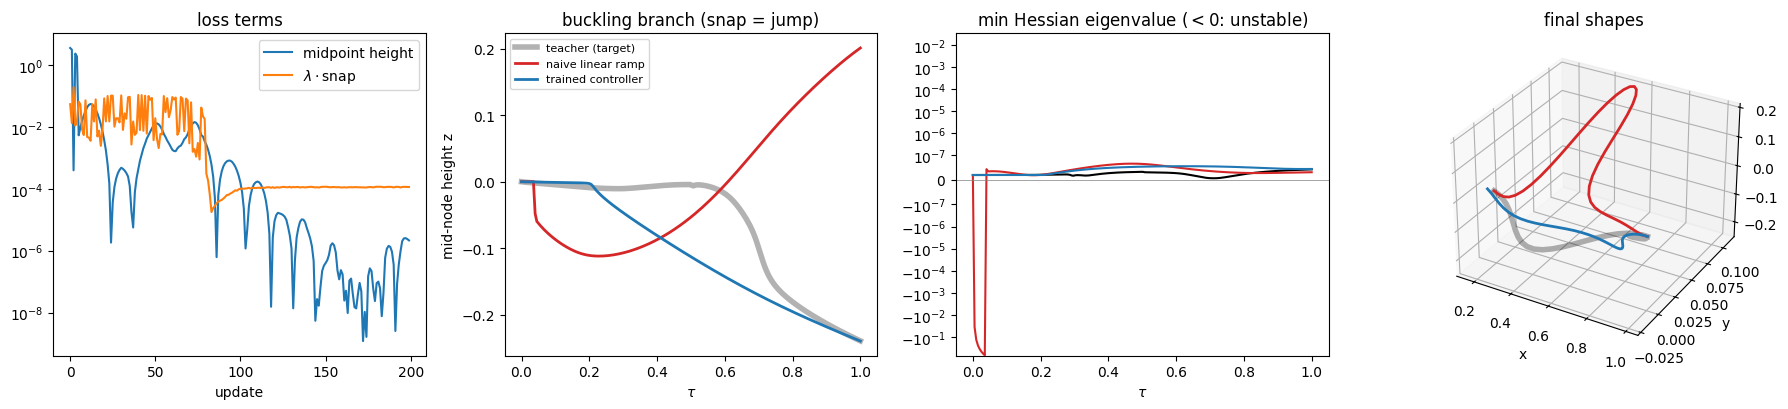

In [8]:
colors = {"teacher (target)": "k", "naive linear ramp": "tab:red", "trained controller": "tab:blue"}
fig = plt.figure(figsize=(18, 4.2))

ax = fig.add_subplot(1, 4, 1)
h = np.array(history)
ax.semilogy(h[:, 1], label="midpoint height"); ax.semilogy(LAMBDA * h[:, 2], label=r"$\lambda\cdot$snap")
ax.set_title("loss terms"); ax.set_xlabel("update"); ax.legend()

ax = fig.add_subplot(1, 4, 2)
for name, d in D.items():
    ax.plot(np.asarray(tau_t), np.asarray(d["q"][:, MID + 2]), color=colors[name], label=name, lw=2 if "teacher" not in name else 4, alpha=1 if "teacher" not in name else .3)
ax.set_xlabel(r"$\tau$"); ax.set_ylabel("mid-node height z"); ax.set_title("buckling branch (snap = jump)"); ax.legend(fontsize=8)

ax = fig.add_subplot(1, 4, 3)
for name, d in D.items():
    ax.plot(np.asarray(tau_t), d["lam"], color=colors[name], label=name)
ax.axhline(0, color="gray", lw=.5); ax.set_yscale("symlog", linthresh=1e-7)
ax.set_xlabel(r"$\tau$"); ax.set_title(r"min Hessian eigenvalue ($<0$: unstable)")

ax = fig.add_subplot(1, 4, 4, projection="3d")
for name, d in D.items():
    q = np.asarray(d["q"][-1]); ax.plot(q[0::4], q[1::4], q[2::4], color=colors[name], lw=4 if "teacher" in name else 2, alpha=.3 if "teacher" in name else 1, label=name)
ax.set_title("final shapes"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout(); plt.show()

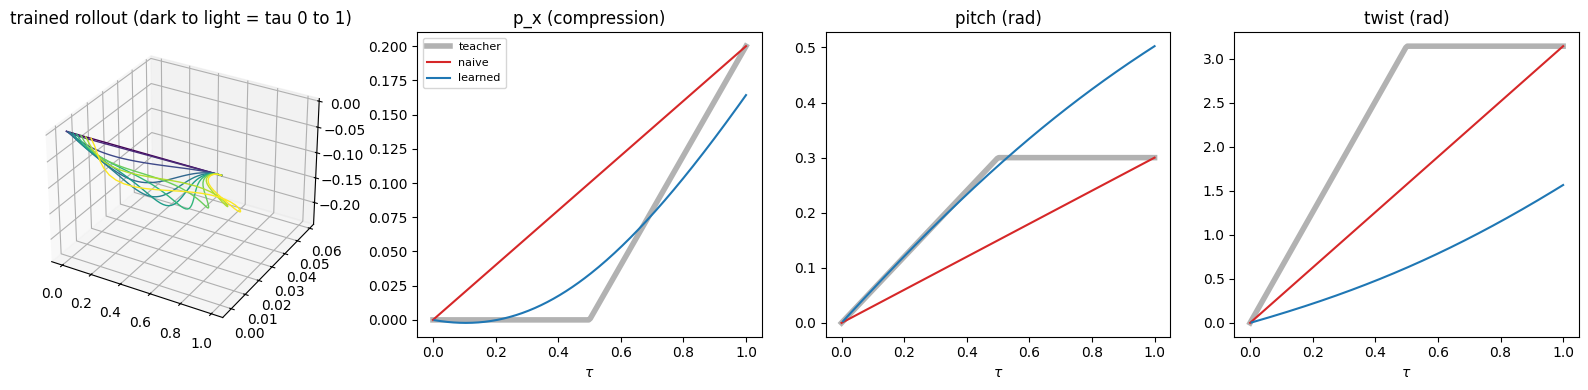

In [9]:
d = D["trained controller"]
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 4, 1, projection="3d")
for k in np.linspace(0, K - 1, 10).astype(int):
    q = np.asarray(d["q"][k]); ax.plot(q[0::4], q[1::4], q[2::4], color=plt.cm.viridis(k / K), lw=1)
ax.set_title("trained rollout (dark to light = tau 0 to 1)")
for i, name in enumerate(["p_x (compression)", "pitch (rad)", "twist (rad)"]):
    ax = fig.add_subplot(1, 4, i + 2)
    ax.plot(np.asarray(tau_t), np.asarray(teacher[:, i]), "k-", lw=4, alpha=.3, label="teacher")
    ax.plot(np.asarray(tau_t), np.asarray(naive[:, i]), color="tab:red", label="naive")
    ax.plot(np.asarray(taus), np.asarray(pose[:, i]), color="tab:blue", label="learned")
    ax.set_title(name); ax.set_xlabel(r"$\tau$")
    if i == 0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Notes

* **One coordinate is enough to steer.** The loss sees only $z_\text{mid}$, yet the trained controller avoids the snap: every step is a stable, converged equilibrium, and the ribbon ends on the target branch.
* **Why the gradient is dense.** $\partial\mathcal L/\partial x_k$ is one-hot, but the adjoint solve with the full free-DOF Hessian $\partial^2E/\partial x^2$ turns it into a sensitivity for every clamp DOF through all nodes and twist angles. Without the equilibrium constraint, a loss on one coordinate would carry far less information about the controls.
* **The unseen shape.** The full-shape error is not used in training and is only reported. It shrinks from about $1.25$ (naive) to about $0.13$: matching the midpoint height on the correct, stable branch recovers most of the target shape. The rest is a real ambiguity, since many twisted and buckled shapes share the same midpoint height. The dense-supervision notebook reaches about $3\times10^{-3}$.
* **Tuning.** The midpoint signal is weaker and less smooth than the full-shape loss, so it needs a stronger snap penalty and a smaller Adam step. With $\lambda=3\times10^{-4}$ and step $3\times10^{-3}$ (or the original $10^{-2}$), training matches the height but ends with 11 unstable or unconverged steps.